# Financial Returns Prediction with Topic-Level EPI (XGBoost)

This notebook extends `513_financial_xgboost` to use the full set of topic-level EPI signals from `data/epi_data.json`. We generate lags for each topic, apply feature selection to keep the most predictive signals, and evaluate how topics relate to asset returns.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Display and plotting options
pd.options.display.float_format = "{:.4f}".format
plt.rcParams["figure.figsize"] = (10, 4)

DATA_DIR = "./data/"
OUTPUT_DIR = "./data/"

RAW_FINANCIAL_FILE = DATA_DIR + "market_data.json"
EPI_FILE = DATA_DIR + "epi_data.json"

# Analysis window
START_DATE = "2025-01-01"
END_DATE = "2025-05-31"

# Topic configuration (focus set provided by user for reporting)
TOPIC_FOCUS = [
    "epi_Environmental and Infrastructure",
    "epi_Labor and Workforce",
    "epi_Health and Social Welfare",
    "epi_Legal and Regulatory Framework",
    "epi_Education and Knowledge",
    "epi_Psychological and Emotional Aspects",
    "epi_Leadership and Governance",
    "epi_Economic and Financial Matters",
    "epi_Disaster and Resilience",
]

TOPIC_MAX_LAG = 3  # lag depth for topic EPI features



## 1. Load and Prepare Data

Load financial data, merge topic-level EPI signals, and build returns/control variables.



In [2]:
# --- Load raw financial data ---
try:
    df_raw = pd.read_json(RAW_FINANCIAL_FILE)
except ValueError:
    df_raw = pd.read_csv(RAW_FINANCIAL_FILE)

# Parse dates and sort
if "Date_" in df_raw.columns:
    df_raw["Date_"] = pd.to_datetime(df_raw["Date_"])
    df_raw = df_raw.sort_values("Date_").set_index("Date_")
else:
    raise KeyError("Expected a 'Date_' column.")

print(f"Loaded {len(df_raw)} rows of financial data")
print(f"Date range: {df_raw.index.min()} to {df_raw.index.max()}")

Loaded 367 rows of financial data
Date range: 2024-11-18 00:00:00 to 2025-11-19 00:00:00


In [3]:
# Rename columns to simpler names
rename_map = {
    "Close_BTC-USD": "close_btc",
    "Close_GC=F": "close_gold",
    "Close_CL=F": "close_oil",
    "Close_^GSPC": "close_spx",
    "Close_CNY=X": "close_usdcny",
    "Close_EUR=X": "close_eurusd",
    "Close_^TNX": "close_ust10y",
    "Volume_BTC-USD": "vol_btc",
    "Volume_GC=F": "vol_gold",
    "Volume_^GSPC": "vol_spx",
}

df = df_raw.rename(columns=rename_map)

# Create business day index and forward-fill prices
full_index = pd.date_range(df.index.min(), df.index.max(), freq="B")
df = df.reindex(full_index)

price_cols = [c for c in df.columns if c.startswith("close_")]
df[price_cols] = df[price_cols].ffill()

print("Data prepared with forward-filled prices")

Data prepared with forward-filled prices


In [4]:
# Construct returns and control variables
def log_return(series):
    return np.log(series).diff()

returns = pd.DataFrame(index=df.index)

# Asset returns (target variables)
returns["r_btc"] = log_return(df["close_btc"])
returns["r_gold"] = log_return(df["close_gold"])
returns["r_spx"] = log_return(df["close_spx"])

# Control variables (features)
returns["dln_eurusd"] = log_return(df["close_eurusd"])
returns["dln_usdcny"] = log_return(df["close_usdcny"])
returns["dln_oil"] = log_return(df["close_oil"])
returns["dy10"] = df["close_ust10y"].diff()

# Drop initial NaNs and restrict to analysis window
returns = returns.dropna()
returns = returns.loc[START_DATE:END_DATE]

print(f"Returns data shape: {returns.shape}")
print(f"Date range: {returns.index.min()} to {returns.index.max()}")

Returns data shape: (108, 7)
Date range: 2025-01-01 00:00:00 to 2025-05-30 00:00:00


In [6]:
# Load and merge EPI data
df_epi = pd.read_json(EPI_FILE)
df_epi['date'] = pd.to_datetime(df_epi['date'])
df_epi = df_epi.set_index('date')

# Identify topic-level columns (exclude aggregate epi/epi_weighted and placeholder column)
topic_cols_all = sorted([
    col for col in df_epi.columns
    if col.startswith('epi_') and col not in ['epi', 'epi_weighted', 'epi_']
])

# Focus subset from user request (for reporting)
focus_topic_cols = [col for col in TOPIC_FOCUS if col in topic_cols_all]
missing_focus = sorted(set(TOPIC_FOCUS) - set(focus_topic_cols))
if missing_focus:
    print(f"Missing requested topics (not found in data): {missing_focus}")

epi_cols = ["epi", "epi_weighted"] + topic_cols_all

# Merge on index (date)
returns = returns.join(df_epi[epi_cols], how='left')
returns[epi_cols] = returns[epi_cols].fillna(0)

print(f"EPI data merged with {len(topic_cols_all)} topic columns.")
print(f"Focus topics available: {focus_topic_cols}")
print(f"Shape: {returns.shape}")



EPI data merged with 18 topic columns.
Focus topics available: ['epi_Environmental and Infrastructure', 'epi_Labor and Workforce', 'epi_Health and Social Welfare', 'epi_Legal and Regulatory Framework', 'epi_Education and Knowledge', 'epi_Psychological and Emotional Aspects', 'epi_Leadership and Governance', 'epi_Economic and Financial Matters', 'epi_Disaster and Resilience']
Shape: (108, 27)


## 2. Feature Engineering

Create lagged features for returns and EPI variables.

In [8]:
# Create lagged features
max_lag = 5
data = returns.copy()

# Create lagged returns for each asset
for asset in ["r_btc", "r_gold", "r_spx"]:
    for lag in range(1, max_lag + 1):
        data[f"{asset}_l{lag}"] = data[asset].shift(lag)

# Topic-level EPI lags and short moving average
topic_feature_cols = []
for topic in topic_cols_all:
    topic_feature_cols.append(topic)  # contemporaneous value
    for lag in range(1, TOPIC_MAX_LAG + 1):
        lag_col = f"{topic}_l{lag}"
        data[lag_col] = data[topic].shift(lag)
        topic_feature_cols.append(lag_col)
    roll_col = f"{topic}_ma5"
    data[roll_col] = data[topic].rolling(5).mean()
    topic_feature_cols.append(roll_col)

# Create volatility features
for asset in ["r_btc", "r_gold", "r_spx"]:
    data[f"{asset}_vol5"] = data[asset].rolling(5).std()

# Drop NaN rows
data = data.dropna()

print(f"Feature-engineered data shape: {data.shape}")
print(f"Number of observations: {len(data)}")
print(f"Topic feature count: {len(topic_feature_cols)} (lags 1-{TOPIC_MAX_LAG} + 5d mean)")



Feature-engineered data shape: (103, 117)
Number of observations: 103
Topic feature count: 90 (lags 1-3 + 5d mean)


## 3. Define Feature Sets

Define different feature sets for model comparison:
- **Baseline**: Only control variables and lagged returns
- **+ EPI**: Add contemporaneous EPI
- **+ EPI Weighted**: Add topic-weighted EPI
- **+ EPI Lagged**: Add lagged EPI (t-1 to t-5)
- **+ EPI Full**: All EPI features (lagged, asymmetric, rolling stats)

In [10]:
# Define control columns
control_cols = ["dln_eurusd", "dln_usdcny", "dln_oil", "dy10"]

# Define feature sets for each model specification
def get_feature_cols(asset, model_type="baseline"):
    """
    Get feature columns for a given asset and model type.
    
    Model types:
    - baseline: lagged returns + controls + volatility
    - topics_all: baseline + all topic EPI features (contemporaneous, lags, 5d mean)
    - topics_focus: baseline + only user-specified focus topics (and derived lags)
    """
    # Base features: lagged returns for the target asset
    lag_cols = [f"{asset}_l{lag}" for lag in range(1, 4)]  # Use 3 lags
    
    # Cross-asset lagged returns (information from other markets)
    other_assets = [a for a in ["r_btc", "r_gold", "r_spx"] if a != asset]
    cross_cols = [f"{a}_l1" for a in other_assets]  # Only lag-1 for other assets
    
    # Volatility features
    vol_cols = [f"{asset}_vol5"]
    
    base_features = lag_cols + cross_cols + control_cols + vol_cols
    
    if model_type == "baseline":
        return base_features
    
    elif model_type == "topics_all":
        return base_features + topic_feature_cols
    
    elif model_type == "topics_focus":
        focus_features = [f for f in topic_feature_cols if any(f.startswith(t) for t in focus_topic_cols)]
        if not focus_features:  # fallback if focus list missing in data
            focus_features = topic_feature_cols
        return base_features + focus_features
    
    else:
        raise ValueError(f"Unknown model type: {model_type}")

# Show example feature sets
print("Feature sets for r_btc:")
for mtype in ["baseline", "topics_all", "topics_focus"]:
    cols = get_feature_cols("r_btc", mtype)
    print(f"{mtype}: {len(cols)} features")
    print(f"  {cols}")



Feature sets for r_btc:
baseline: 10 features
  ['r_btc_l1', 'r_btc_l2', 'r_btc_l3', 'r_gold_l1', 'r_spx_l1', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'r_btc_vol5']
topics_all: 100 features
  ['r_btc_l1', 'r_btc_l2', 'r_btc_l3', 'r_gold_l1', 'r_spx_l1', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'r_btc_vol5', 'epi_Conspiracy and Historical Events', 'epi_Conspiracy and Historical Events_l1', 'epi_Conspiracy and Historical Events_l2', 'epi_Conspiracy and Historical Events_l3', 'epi_Conspiracy and Historical Events_ma5', 'epi_Disaster and Resilience', 'epi_Disaster and Resilience_l1', 'epi_Disaster and Resilience_l2', 'epi_Disaster and Resilience_l3', 'epi_Disaster and Resilience_ma5', 'epi_Disputes and Opinions', 'epi_Disputes and Opinions_l1', 'epi_Disputes and Opinions_l2', 'epi_Disputes and Opinions_l3', 'epi_Disputes and Opinions_ma5', 'epi_Economic and Financial Matters', 'epi_Economic and Financial Matters_l1', 'epi_Economic and Financial Matters_l2', 'epi_Economic and Fi

## 4. XGBoost Model Training Functions

Define functions for training XGBoost models with:
- Rolling window cross-validation (time series aware)
- **Advanced hyperparameter tuning** with regularization (L1/L2)
- **Feature selection** based on importance scores
- Evaluation metrics (RMSE, MAE, Directional Accuracy)

### Key Improvements:
1. **Regularization**: `reg_alpha` (L1) and `reg_lambda` (L2) to prevent overfitting
2. **Sampling**: `subsample` and `colsample_bytree` for better generalization
3. **Tree constraints**: `min_child_weight` to avoid fitting noise
4. **Feature selection**: Remove low-importance features to reduce noise

In [11]:
def train_xgboost_rolling(data, asset, feature_cols, min_train=60, 
                          n_estimators=100, max_depth=3, learning_rate=0.1,
                          reg_alpha=0.1, reg_lambda=1.0, min_child_weight=3,
                          subsample=0.8, colsample_bytree=0.8,
                          scale_features=True):
    """
    Train XGBoost with rolling window forecasts (expanding window).
    
    Includes regularization parameters to prevent overfitting:
    - reg_alpha: L1 regularization (encourages sparsity)
    - reg_lambda: L2 regularization (penalizes large weights)
    - min_child_weight: Minimum sum of instance weight in a child
    - subsample: Fraction of samples used for training each tree
    - colsample_bytree: Fraction of features used for each tree
    
    Returns:
        dict: Results including RMSE, MAE, directional accuracy, and predictions
    """
    # Prepare data
    df_fit = data.dropna(subset=[asset] + feature_cols)
    
    if len(df_fit) <= min_train:
        return {"error": "Insufficient data"}
    
    y = df_fit[asset].values
    X = df_fit[feature_cols].values
    dates = df_fit.index
    
    # Initialize scaler if needed
    scaler = StandardScaler() if scale_features else None
    
    # Rolling predictions
    preds, actuals, pred_dates = [], [], []
    
    for i in range(min_train, len(df_fit)):
        # Training data (expanding window)
        X_train, y_train = X[:i], y[:i]
        X_test = X[i:i+1]
        
        # Scale features
        if scale_features:
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
        else:
            X_train_scaled, X_test_scaled = X_train, X_test
        
        # Train XGBoost with regularization
        model = XGBRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            reg_alpha=reg_alpha,          # L1 regularization
            reg_lambda=reg_lambda,        # L2 regularization
            min_child_weight=min_child_weight,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            random_state=42,
            verbosity=0,
            n_jobs=-1
        )
        model.fit(X_train_scaled, y_train)
        
        # Predict
        pred = model.predict(X_test_scaled)[0]
        
        preds.append(pred)
        actuals.append(y[i])
        pred_dates.append(dates[i])
    
    # Convert to arrays
    preds = np.array(preds)
    actuals = np.array(actuals)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    
    # Directional accuracy
    dir_correct = np.sign(preds) == np.sign(actuals)
    dir_acc = np.mean(dir_correct) * 100
    
    return {
        "rmse": rmse,
        "mae": mae,
        "dir_acc": dir_acc,
        "n_predictions": len(preds),
        "predictions": pd.Series(preds, index=pred_dates),
        "actuals": pd.Series(actuals, index=pred_dates)
    }

In [12]:
def train_xgboost_with_tuning(data, asset, feature_cols, min_train=60, n_splits=3):
    """
    Train XGBoost with ADVANCED hyperparameter tuning using TimeSeriesSplit.
    
    Includes:
    - Regularization parameters (reg_alpha, reg_lambda)
    - Sampling parameters (subsample, colsample_bytree)
    - Tree complexity controls (max_depth, min_child_weight)
    
    Returns:
        dict: Results including best parameters and performance metrics
    """
    # Prepare data
    df_fit = data.dropna(subset=[asset] + feature_cols)
    
    if len(df_fit) <= min_train:
        return {"error": "Insufficient data"}
    
    y = df_fit[asset].values
    X = df_fit[feature_cols].values
    dates = df_fit.index
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # IMPROVED: Expanded parameter grid with regularization
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [2, 3, 4],
        'learning_rate': [0.01, 0.05, 0.1],      # Lower learning rates
        'reg_alpha': [0, 0.1, 1.0],               # L1 regularization
        'reg_lambda': [1.0, 5.0, 10.0],           # L2 regularization
        'min_child_weight': [1, 3, 5],            # Prevent overfitting
        'subsample': [0.7, 0.8, 0.9],             # Row sampling
        'colsample_bytree': [0.7, 0.8, 0.9]       # Feature sampling
    }
    
    # Time series cross-validation
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    # Grid search with RandomizedSearchCV for efficiency
    from sklearn.model_selection import RandomizedSearchCV
    
    model = XGBRegressor(random_state=42, verbosity=0, n_jobs=-1)
    
    random_search = RandomizedSearchCV(
        model, 
        param_grid, 
        cv=tscv, 
        scoring='neg_mean_squared_error',
        n_iter=50,  # Number of random combinations to try
        n_jobs=-1,
        verbose=0,
        random_state=42
    )
    
    # Fit on training portion
    train_size = int(len(X_scaled) * 0.8)
    random_search.fit(X_scaled[:train_size], y[:train_size])
    
    best_params = random_search.best_params_
    
    # Now do rolling forecasts with best parameters
    result = train_xgboost_rolling(
        data, asset, feature_cols, min_train,
        n_estimators=best_params['n_estimators'],
        max_depth=best_params['max_depth'],
        learning_rate=best_params['learning_rate'],
        reg_alpha=best_params['reg_alpha'],
        reg_lambda=best_params['reg_lambda'],
        min_child_weight=best_params['min_child_weight'],
        subsample=best_params['subsample'],
        colsample_bytree=best_params['colsample_bytree']
    )
    
    result['best_params'] = best_params
    result['cv_score'] = -random_search.best_score_  # Convert back to positive MSE
    
    return result


def select_features_by_importance(data, asset, feature_cols, threshold=0.01, min_train=60):
    """
    Select features based on XGBoost feature importance.
    
    Removes features with importance below threshold to reduce noise.
    
    Args:
        threshold: Minimum importance score to keep a feature (default 0.01 = 1%)
    
    Returns:
        list: Selected feature columns
    """
    df_fit = data.dropna(subset=[asset] + feature_cols)
    
    if len(df_fit) <= min_train:
        return feature_cols  # Return all if insufficient data
    
    y = df_fit[asset].values
    X = df_fit[feature_cols].values
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train model on all data to get importance
    model = XGBRegressor(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        verbosity=0
    )
    model.fit(X_scaled, y)
    
    # Get feature importance
    importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Select features above threshold
    selected = importance[importance['importance'] >= threshold]['feature'].tolist()
    
    # Ensure we keep at least 3 features
    if len(selected) < 3:
        selected = importance.head(3)['feature'].tolist()
    
    return selected, importance

## 5. Train Baseline XGBoost Models

Train XGBoost models without EPI features to establish a baseline.

In [13]:
# Train baseline XGBoost for each asset WITH FEATURE SELECTION
print("=" * 70)
print("BASELINE XGBOOST MODELS (No EPI) - With Feature Selection")
print("=" * 70)

assets = ["r_btc", "r_gold", "r_spx"]
baseline_results = {}
selected_features = {}  # Store selected features for each asset

for asset in assets:
    feature_cols = get_feature_cols(asset, "baseline")
    print(f"\n{asset}: Starting with {len(feature_cols)} features")
    
    # STEP 1: Feature Selection
    selected, importance_df = select_features_by_importance(
        data, asset, feature_cols, threshold=0.02  # Keep features with >2% importance
    )
    selected_features[asset] = selected
    
    print(f"  → Selected {len(selected)} features (removed {len(feature_cols) - len(selected)} low-importance)")
    print(f"  → Top features: {selected[:5]}")
    
    # STEP 2: Train with selected features and regularization
    result = train_xgboost_rolling(
        data, asset, selected,
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,      # Lower learning rate
        reg_alpha=0.1,           # L1 regularization
        reg_lambda=1.0,          # L2 regularization
        min_child_weight=3,      # Prevent overfitting
        subsample=0.8,           # Row sampling
        colsample_bytree=0.8     # Feature sampling
    )
    baseline_results[asset] = result
    
    if "error" not in result:
        print(f"  RMSE: {result['rmse']:.5f}")
        print(f"  MAE: {result['mae']:.5f}")
        print(f"  Directional Accuracy: {result['dir_acc']:.2f}%")
    else:
        print(f"  Error: {result['error']}")

BASELINE XGBOOST MODELS (No EPI) - With Feature Selection

r_btc: Starting with 10 features
  → Selected 9 features (removed 1 low-importance)
  → Top features: ['dln_oil', 'r_gold_l1', 'r_btc_l3', 'dy10', 'r_btc_vol5']
  RMSE: 0.02543
  MAE: 0.01916
  Directional Accuracy: 53.49%

r_gold: Starting with 10 features
  → Selected 7 features (removed 3 low-importance)
  → Top features: ['r_gold_vol5', 'dln_usdcny', 'dln_eurusd', 'r_btc_l1', 'r_gold_l3']
  RMSE: 0.01929
  MAE: 0.01579
  Directional Accuracy: 44.19%

r_spx: Starting with 10 features
  → Selected 9 features (removed 1 low-importance)
  → Top features: ['dln_oil', 'r_spx_l3', 'r_spx_vol5', 'r_spx_l1', 'dln_eurusd']
  RMSE: 0.02288
  MAE: 0.01460
  Directional Accuracy: 41.86%


## 6. Train XGBoost Models with EPI Features

Train models with different EPI feature configurations.

In [15]:
# Train XGBoost with topic-level EPI configurations - WITH FEATURE SELECTION & REGULARIZATION
print("=" * 70)
print("XGBOOST MODELS WITH TOPIC-LEVEL EPI FEATURES")
print("=" * 70)

model_types = ["topics_all", "topics_focus"]
all_results = {}
all_selected_features = {}  # Track selected features for each model

for model_type in model_types:
    print(f"{'='*50}")
    print(f"Model: {model_type}")
    print(f"{'='*50}")
    
    all_results[model_type] = {}
    all_selected_features[model_type] = {}
    
    for asset in assets:
        feature_cols = get_feature_cols(asset, model_type)
        
        # STEP 1: Feature Selection (keep features with >1% importance)
        selected, importance_df = select_features_by_importance(
            data, asset, feature_cols, threshold=0.01
        )
        all_selected_features[model_type][asset] = selected
        
        print(f"{asset}: {len(feature_cols)} → {len(selected)} features")
        
        # STEP 2: Train with regularization
        result = train_xgboost_rolling(
            data, asset, selected,
            n_estimators=120,
            max_depth=3,
            learning_rate=0.05,      # Lower learning rate for stability
            reg_alpha=0.15,          # L1 regularization
            reg_lambda=1.0,          # L2 regularization
            min_child_weight=3,      # Prevent overfitting
            subsample=0.8,           # Row sampling
            colsample_bytree=0.8     # Feature sampling
        )
        all_results[model_type][asset] = result
        
        if "error" not in result:
            print(f"  RMSE: {result['rmse']:.5f}")
            print(f"  Dir Acc: {result['dir_acc']:.2f}%")
        else:
            print(f"  Error: {result['error']}")



XGBOOST MODELS WITH TOPIC-LEVEL EPI FEATURES
Model: topics_all
r_btc: 100 → 37 features
  RMSE: 0.02688
  Dir Acc: 62.79%
r_gold: 100 → 40 features
  RMSE: 0.01865
  Dir Acc: 44.19%
r_spx: 100 → 33 features
  RMSE: 0.02204
  Dir Acc: 51.16%
Model: topics_focus
r_btc: 55 → 38 features
  RMSE: 0.02705
  Dir Acc: 60.47%
r_gold: 55 → 26 features
  RMSE: 0.01869
  Dir Acc: 48.84%
r_spx: 55 → 28 features
  RMSE: 0.02224
  Dir Acc: 53.49%


## 7. Model Comparison Summary

Compare baseline vs topic-level EPI configurations.



In [16]:
# Create comparison dataframe
comparison_data = []

# Add baseline results
for asset in assets:
    result = baseline_results[asset]
    if "error" not in result:
        comparison_data.append({
            "Model": "Baseline",
            "Asset": asset,
            "RMSE": result["rmse"],
            "MAE": result["mae"],
            "Dir Acc (%)": result["dir_acc"]
        })

# Add EPI model results
for model_type in model_types:
    for asset in assets:
        result = all_results[model_type][asset]
        if "error" not in result:
            comparison_data.append({
                "Model": f"+ {model_type}",
                "Asset": asset,
                "RMSE": result["rmse"],
                "MAE": result["mae"],
                "Dir Acc (%)": result["dir_acc"]
            })

comparison_df = pd.DataFrame(comparison_data)

print("=" * 70)
print("XGBOOST MODEL COMPARISON SUMMARY")
print("=" * 70)

# RMSE comparison
print("\n📊 RMSE Comparison (lower is better):")
rmse_pivot = comparison_df.pivot(index="Model", columns="Asset", values="RMSE").round(5)
display(rmse_pivot)

# Directional Accuracy comparison
print("\n🎯 Directional Accuracy Comparison (%, higher is better):")
dir_pivot = comparison_df.pivot(index="Model", columns="Asset", values="Dir Acc (%)").round(2)
display(dir_pivot)

XGBOOST MODEL COMPARISON SUMMARY

📊 RMSE Comparison (lower is better):


Asset,r_btc,r_gold,r_spx
Model,,,
+ topics_all,0.0269,0.0186,0.0220
+ topics_focus,0.0271,0.0187,0.0222
Baseline,0.0254,0.0193,0.0229



🎯 Directional Accuracy Comparison (%, higher is better):


Asset,r_btc,r_gold,r_spx
Model,,,
+ topics_all,62.7900,44.1900,51.1600
+ topics_focus,60.4700,48.8400,53.4900
Baseline,53.4900,44.1900,41.8600


In [17]:
# Calculate improvement over baseline
print("=" * 70)
print("IMPROVEMENT OVER BASELINE")
print("=" * 70)

improvement_data = []

for asset in assets:
    baseline_rmse = baseline_results[asset]["rmse"]
    baseline_dir = baseline_results[asset]["dir_acc"]
    
    for model_type in model_types:
        result = all_results[model_type][asset]
        if "error" not in result:
            rmse_imp = (baseline_rmse - result["rmse"]) / baseline_rmse * 100
            dir_imp = result["dir_acc"] - baseline_dir
            
            improvement_data.append({
                "Model": f"+ {model_type}",
                "Asset": asset,
                "RMSE Improvement (%)": rmse_imp,
                "Dir Acc Improvement (pp)": dir_imp
            })

improvement_df = pd.DataFrame(improvement_data)

print("\nRMSE Improvement over Baseline (%, positive = better):")
display(improvement_df.pivot(index="Model", columns="Asset", values="RMSE Improvement (%)").round(2))

print("\nDirectional Accuracy Improvement (percentage points):")
display(improvement_df.pivot(index="Model", columns="Asset", values="Dir Acc Improvement (pp)").round(2))

IMPROVEMENT OVER BASELINE

RMSE Improvement over Baseline (%, positive = better):


Asset,r_btc,r_gold,r_spx
Model,,,
+ topics_all,-5.7000,3.2900,3.6900
+ topics_focus,-6.3600,3.1100,2.8100



Directional Accuracy Improvement (percentage points):


Asset,r_btc,r_gold,r_spx
Model,,,
+ topics_all,9.3000,0.0000,9.3000
+ topics_focus,6.9800,4.6500,11.6300


## 7b. Overfitting Diagnostic

Check for overfitting by comparing **training RMSE vs test RMSE**. 
- If training RMSE << test RMSE → **Overfitting** (model memorizes training data)
- If training RMSE ≈ test RMSE → **Good generalization**
- If both are high → **Underfitting** (model too simple)

In [19]:
# ============================================================
# OVERFITTING DIAGNOSTIC: Compare Train vs Test Performance
# ============================================================

def diagnose_overfitting(data, asset, feature_cols, min_train=60,
                         n_estimators=100, max_depth=3, learning_rate=0.05,
                         reg_alpha=0.1, reg_lambda=1.0, min_child_weight=3,
                         subsample=0.8, colsample_bytree=0.8):
    """
    Diagnose overfitting by comparing training vs out-of-sample performance.
    
    Returns train RMSE, test RMSE, and overfitting ratio.
    """
    df_fit = data.dropna(subset=[asset] + feature_cols)
    
    if len(df_fit) <= min_train:
        return {"error": "Insufficient data"}
    
    y = df_fit[asset].values
    X = df_fit[feature_cols].values
    
    scaler = StandardScaler()
    
    train_rmses, test_rmses = [], []
    train_preds_all, train_actuals_all = [], []
    
    for i in range(min_train, len(df_fit)):
        X_train, y_train = X[:i], y[:i]
        X_test = X[i:i+1]
        y_test = y[i]
        
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        model = XGBRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            min_child_weight=min_child_weight,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            random_state=42,
            verbosity=0
        )
        model.fit(X_train_scaled, y_train)
        
        # Training predictions (in-sample)
        train_pred = model.predict(X_train_scaled)
        train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
        train_rmses.append(train_rmse)
        
        # Test prediction (out-of-sample)
        test_pred = model.predict(X_test_scaled)[0]
        test_rmses.append((test_pred - y_test) ** 2)
    
    avg_train_rmse = np.mean(train_rmses)
    avg_test_rmse = np.sqrt(np.mean(test_rmses))
    
    # Overfitting ratio: test/train (>1.5 suggests overfitting)
    overfit_ratio = avg_test_rmse / avg_train_rmse if avg_train_rmse > 0 else np.inf
    
    return {
        "train_rmse": avg_train_rmse,
        "test_rmse": avg_test_rmse,
        "overfit_ratio": overfit_ratio,
        "diagnosis": "OVERFITTING" if overfit_ratio > 2.0 else 
                     "SLIGHT OVERFIT" if overfit_ratio > 1.5 else
                     "GOOD" if overfit_ratio > 0.8 else "UNDERFITTING"
    }


print("=" * 70)
print("OVERFITTING DIAGNOSTIC")
print("=" * 70)
print("Overfit Ratio = Test RMSE / Train RMSE")
print("  > 2.0: OVERFITTING (model memorizes training data)")
print("  1.5-2.0: SLIGHT OVERFIT (some generalization issues)")
print("  0.8-1.5: GOOD (healthy generalization)")
print("  < 0.8: UNDERFITTING (model too simple)")
print()

overfit_results = []

# Test baseline model
print("Testing Baseline models...")
for asset in assets:
    feature_cols = get_feature_cols(asset, "baseline")
    selected, _ = select_features_by_importance(data, asset, feature_cols, threshold=0.02)
    
    result = diagnose_overfitting(data, asset, selected)
    if "error" not in result:
        overfit_results.append({
            "Model": "Baseline",
            "Asset": asset,
            "Train RMSE": result["train_rmse"],
            "Test RMSE": result["test_rmse"],
            "Overfit Ratio": result["overfit_ratio"],
            "Diagnosis": result["diagnosis"]
        })

# Test topic EPI models
print("Testing Topic EPI models...")
for model_type in model_types:
    for asset in assets:
        feature_cols = get_feature_cols(asset, model_type)
        selected, _ = select_features_by_importance(data, asset, feature_cols, threshold=0.01)
        
        result = diagnose_overfitting(data, asset, selected)
        if "error" not in result:
            overfit_results.append({
                "Model": model_type,
                "Asset": asset,
                "Train RMSE": result["train_rmse"],
                "Test RMSE": result["test_rmse"],
                "Overfit Ratio": result["overfit_ratio"],
                "Diagnosis": result["diagnosis"]
            })

overfit_df = pd.DataFrame(overfit_results)

print("📊 Overfitting Results")
print("=" * 70)
display(overfit_df.round(5))

# Summary pivot
print("📊 Overfit Ratio by Model and Asset:")
pivot_overfit = overfit_df.pivot(index="Model", columns="Asset", values="Overfit Ratio").round(2)
display(pivot_overfit)

print("📋 Diagnosis Summary:")
pivot_diagnosis = overfit_df.pivot(index="Model", columns="Asset", values="Diagnosis")
display(pivot_diagnosis)



OVERFITTING DIAGNOSTIC
Overfit Ratio = Test RMSE / Train RMSE
  > 2.0: OVERFITTING (model memorizes training data)
  1.5-2.0: SLIGHT OVERFIT (some generalization issues)
  0.8-1.5: GOOD (healthy generalization)
  < 0.8: UNDERFITTING (model too simple)

Testing Baseline models...
Testing Topic EPI models...
📊 Overfitting Results


,Model,Asset,Train RMSE,Test RMSE,Overfit Ratio,Diagnosis
0,Baseline,r_btc,0.0177,0.0254,1.4395,GOOD
1,Baseline,r_gold,0.0106,0.0193,1.8207,SLIGHT OVERFIT
2,Baseline,r_spx,0.0126,0.0229,1.8112,SLIGHT OVERFIT
3,topics_all,r_btc,0.0128,0.0267,2.0832,OVERFITTING
4,topics_all,r_gold,0.0086,0.0187,2.1807,OVERFITTING
5,topics_all,r_spx,0.0111,0.0221,1.9881,SLIGHT OVERFIT
6,topics_focus,r_btc,0.0134,0.0269,2.0167,OVERFITTING
7,topics_focus,r_gold,0.0092,0.0189,2.0492,OVERFITTING
8,topics_focus,r_spx,0.0111,0.0223,2.0018,OVERFITTING


📊 Overfit Ratio by Model and Asset:


Asset,r_btc,r_gold,r_spx
Model,,,
Baseline,1.4400,1.8200,1.8100
topics_all,2.0800,2.1800,1.9900
topics_focus,2.0200,2.0500,2.0000


📋 Diagnosis Summary:


Asset,r_btc,r_gold,r_spx
Model,,,
Baseline,GOOD,SLIGHT OVERFIT,SLIGHT OVERFIT
topics_all,OVERFITTING,OVERFITTING,SLIGHT OVERFIT
topics_focus,OVERFITTING,OVERFITTING,OVERFITTING


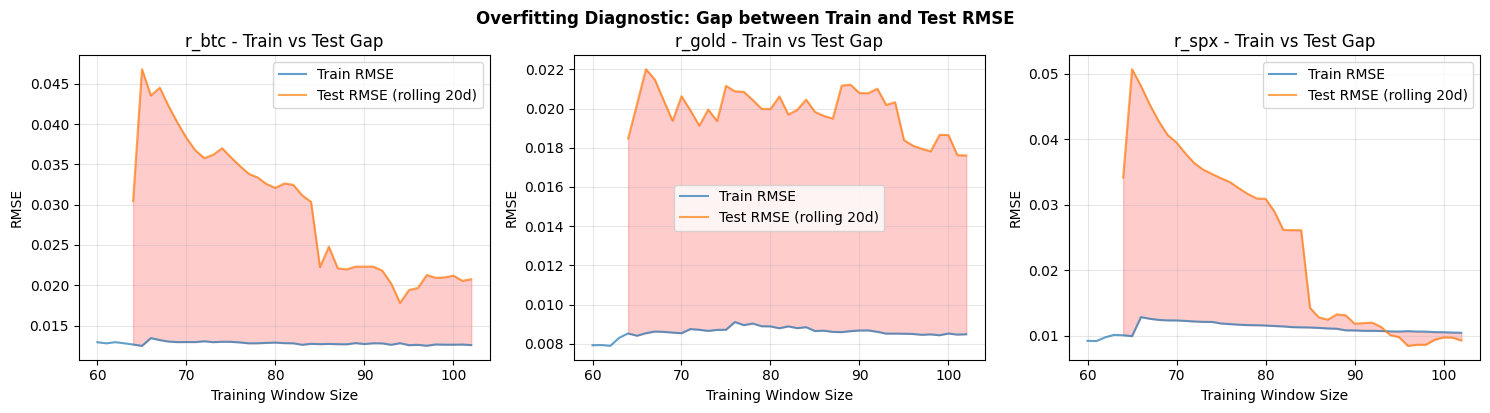

📊 Interpretation:
  - RED SHADED AREA = Overfitting gap (larger = worse)
  - If gap increases over time → Model complexity too high
  - If gap is stable → Good generalization


In [31]:
# ============================================================
# VISUALIZE OVERFITTING: Train vs Test RMSE over time
# ============================================================

def plot_overfitting_over_time(data, asset, feature_cols, min_train=60):
    """Plot how train/test gap evolves as training window expands."""
    
    df_fit = data.dropna(subset=[asset] + feature_cols)
    y = df_fit[asset].values
    X = df_fit[feature_cols].values
    
    scaler = StandardScaler()
    train_rmses, test_errors, window_sizes = [], [], []
    
    for i in range(min_train, len(df_fit)):
        X_train, y_train = X[:i], y[:i]
        X_test = X[i:i+1]
        y_test = y[i]
        
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        model = XGBRegressor(
            n_estimators=100, max_depth=3, learning_rate=0.05,
            reg_alpha=0.1, reg_lambda=1.0, min_child_weight=3,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbosity=0
        )
        model.fit(X_train_scaled, y_train)
        
        train_pred = model.predict(X_train_scaled)
        train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
        
        test_pred = model.predict(X_test_scaled)[0]
        test_error = (test_pred - y_test) ** 2
        
        train_rmses.append(train_rmse)
        test_errors.append(test_error)
        window_sizes.append(i)
    
    # Calculate rolling test RMSE (30-day window)
    test_errors = np.array(test_errors)
    rolling_test_rmse = pd.Series(test_errors).rolling(20, min_periods=5).apply(lambda x: np.sqrt(np.mean(x)))
    
    return window_sizes, train_rmses, rolling_test_rmse.values

# Plot for each asset
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Use best_model_type if defined, otherwise default to "topics_focus"
_model_type = best_model_type if 'best_model_type' in dir() else "topics_focus"

for idx, asset in enumerate(assets):
    feature_cols = get_feature_cols(asset, _model_type)
    selected, _ = select_features_by_importance(data, asset, feature_cols, threshold=0.01)
    
    sizes, train_rmses, test_rmses = plot_overfitting_over_time(data, asset, selected)
    
    ax = axes[idx]
    ax.plot(sizes, train_rmses, label='Train RMSE', alpha=0.7)
    ax.plot(sizes, test_rmses, label='Test RMSE (rolling 20d)', alpha=0.7)
    ax.fill_between(sizes, train_rmses, test_rmses, alpha=0.2, color='red')
    ax.set_title(f'{asset} - Train vs Test Gap')
    ax.set_xlabel('Training Window Size')
    ax.set_ylabel('RMSE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Overfitting Diagnostic: Gap between Train and Test RMSE', y=1.02, fontsize=12, fontweight='bold')
plt.show()

print("📊 Interpretation:")
print("  - RED SHADED AREA = Overfitting gap (larger = worse)")
print("  - If gap increases over time → Model complexity too high")
print("  - If gap is stable → Good generalization")



## 8. Hyperparameter Tuning

Find optimal hyperparameters for the best-performing model configuration.

In [22]:
# Find best model type by average RMSE improvement
avg_improvement = improvement_df.groupby("Model")["RMSE Improvement (%)"].mean()
best_model_type = avg_improvement.idxmax().replace("+ ", "")

print(f"Best model type by avg RMSE improvement: {best_model_type}")
print(f"\nRunning hyperparameter tuning for {best_model_type}...")
print("(This may take a few minutes)\n")

tuned_results = {}

for asset in assets:
    print(f"Tuning {asset}...")
    feature_cols = get_feature_cols(asset, best_model_type)
    
    result = train_xgboost_with_tuning(data, asset, feature_cols, n_splits=3)
    tuned_results[asset] = result
    
    if "error" not in result:
        print(f"  Best params: {result['best_params']}")
        print(f"  RMSE: {result['rmse']:.5f}")
        print(f"  Dir Acc: {result['dir_acc']:.2f}%")
    else:
        print(f"  Error: {result['error']}")

Best model type by avg RMSE improvement: topics_all

Running hyperparameter tuning for topics_all...
(This may take a few minutes)

Tuning r_btc...
  Best params: {'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
  RMSE: 0.02745
  Dir Acc: 39.53%
Tuning r_gold...
  Best params: {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 50, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
  RMSE: 0.01998
  Dir Acc: 48.84%
Tuning r_spx...
  Best params: {'subsample': 0.8, 'reg_lambda': 10.0, 'reg_alpha': 0, 'n_estimators': 50, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
  RMSE: 0.02263
  Dir Acc: 53.49%


In [23]:
# Compare tuned vs default parameters
print("=" * 70)
print("TUNED VS DEFAULT PARAMETERS")
print("=" * 70)

comparison_tuned = []

for asset in assets:
    default_result = all_results[best_model_type][asset]
    tuned_result = tuned_results[asset]
    
    if "error" not in default_result and "error" not in tuned_result:
        comparison_tuned.append({
            "Asset": asset,
            "Default RMSE": default_result["rmse"],
            "Tuned RMSE": tuned_result["rmse"],
            "RMSE Improvement (%)": (default_result["rmse"] - tuned_result["rmse"]) / default_result["rmse"] * 100,
            "Default Dir Acc": default_result["dir_acc"],
            "Tuned Dir Acc": tuned_result["dir_acc"]
        })

display(pd.DataFrame(comparison_tuned).round(4))

TUNED VS DEFAULT PARAMETERS


,Asset,Default RMSE,Tuned RMSE,RMSE Improvement (%),Default Dir Acc,Tuned Dir Acc
0,r_btc,0.0269,0.0275,-2.1296,62.7907,39.5349
1,r_gold,0.0187,0.0200,-7.0896,44.1860,48.8372
2,r_spx,0.0220,0.0226,-2.6809,51.1628,53.4884


## 9. Feature Importance Analysis

Analyze which features are most important for predictions.

FEATURE IMPORTANCE ANALYSIS (TOPIC-LEVEL)
r_btc: top topic signals
  epi_Social and Cultural Aspects: 0.1364
  epi_Quality of Life and Standards: 0.0916
  epi_Environmental and Infrastructure: 0.0870
  epi_Economic and Financial Matters: 0.0703
  epi_Legal and Regulatory Framework: 0.0664
r_gold: top topic signals
  epi_Disputes and Opinions: 0.1238
  epi_Environmental and Infrastructure: 0.0782
  epi_Trust, Credibility, and Communication: 0.0709
  epi_Labor and Workforce: 0.0644
  epi_Psychological and Emotional Aspects: 0.0617
r_spx: top topic signals
  epi_Labor and Workforce: 0.1132
  epi_Economic and Financial Matters: 0.0942
  epi_Sports and Recreation: 0.0658
  epi_Disputes and Opinions: 0.0589
  epi_Legal and Regulatory Framework: 0.0559


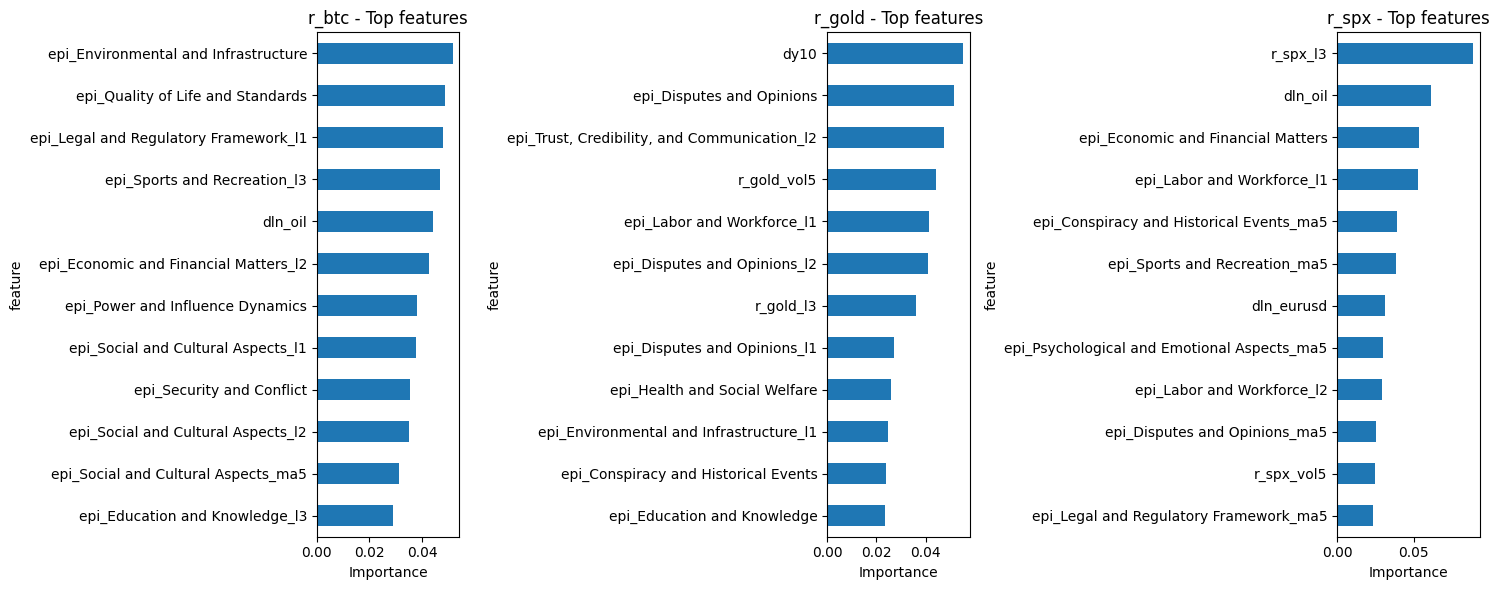

Topic importance (sum across lags/rolling):


,r_btc,r_gold,r_spx
topic,,,
epi_Conspiracy and Historical Events,0.0037,0.0560,0.0459
epi_Disaster and Resilience,0.0122,0.0090,0.0104
epi_Disputes and Opinions,0.0296,0.1238,0.0589
epi_Economic and Financial Matters,0.0703,0.0362,0.0942
epi_Education and Knowledge,0.0448,0.0430,0.0377
epi_Environmental and Infrastructure,0.0870,0.0782,0.0178
epi_Health and Social Welfare,0.0199,0.0527,0.0192
epi_Labor and Workforce,0.0306,0.0644,0.1132
epi_Leadership and Governance,0.0317,0.0243,0.0254


In [25]:
# Train full model on all data to get feature importance
print("=" * 70)
print("FEATURE IMPORTANCE ANALYSIS (TOPIC-LEVEL)")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
topic_importance_summary = {}

for idx, asset in enumerate(assets):
    feature_cols = get_feature_cols(asset, best_model_type)
    
    # Prepare data
    df_fit = data.dropna(subset=[asset] + feature_cols)
    y = df_fit[asset].values
    X = df_fit[feature_cols].values
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train model
    model = XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        random_state=42,
        verbosity=0
    )
    model.fit(X_scaled, y)
    
    # Get feature importance
    importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=True)
    
    # Plot top 12 features
    ax = axes[idx]
    importance.tail(12).plot(kind='barh', x='feature', y='importance', ax=ax, legend=False)
    ax.set_title(f"{asset} - Top features")
    ax.set_xlabel("Importance")
    
    # Aggregate importance by topic (summing across lags/rolling)
    def map_topic(feature):
        for topic in topic_cols_all:
            if feature.startswith(topic):
                return topic
        return 'non_topic'
    
    importance['topic'] = importance['feature'].apply(map_topic)
    topic_imp = (importance.groupby('topic')['importance'].sum()
                 .sort_values(ascending=False))
    topic_importance_summary[asset] = topic_imp
    
    top_topics = topic_imp.drop(index='non_topic', errors='ignore').head(5)
    print(f"{asset}: top topic signals")
    for topic, val in top_topics.items():
        print(f"  {topic}: {val:.4f}")

plt.tight_layout()
plt.show()

# Topic-only view for quick assessment
print("Topic importance (sum across lags/rolling):")
topic_table = pd.DataFrame(topic_importance_summary)
topic_table = topic_table.drop(index='non_topic', errors='ignore').round(4)
display(topic_table)



## 10. Visualization: Predictions vs Actuals

PREDICTIONS VS ACTUALS


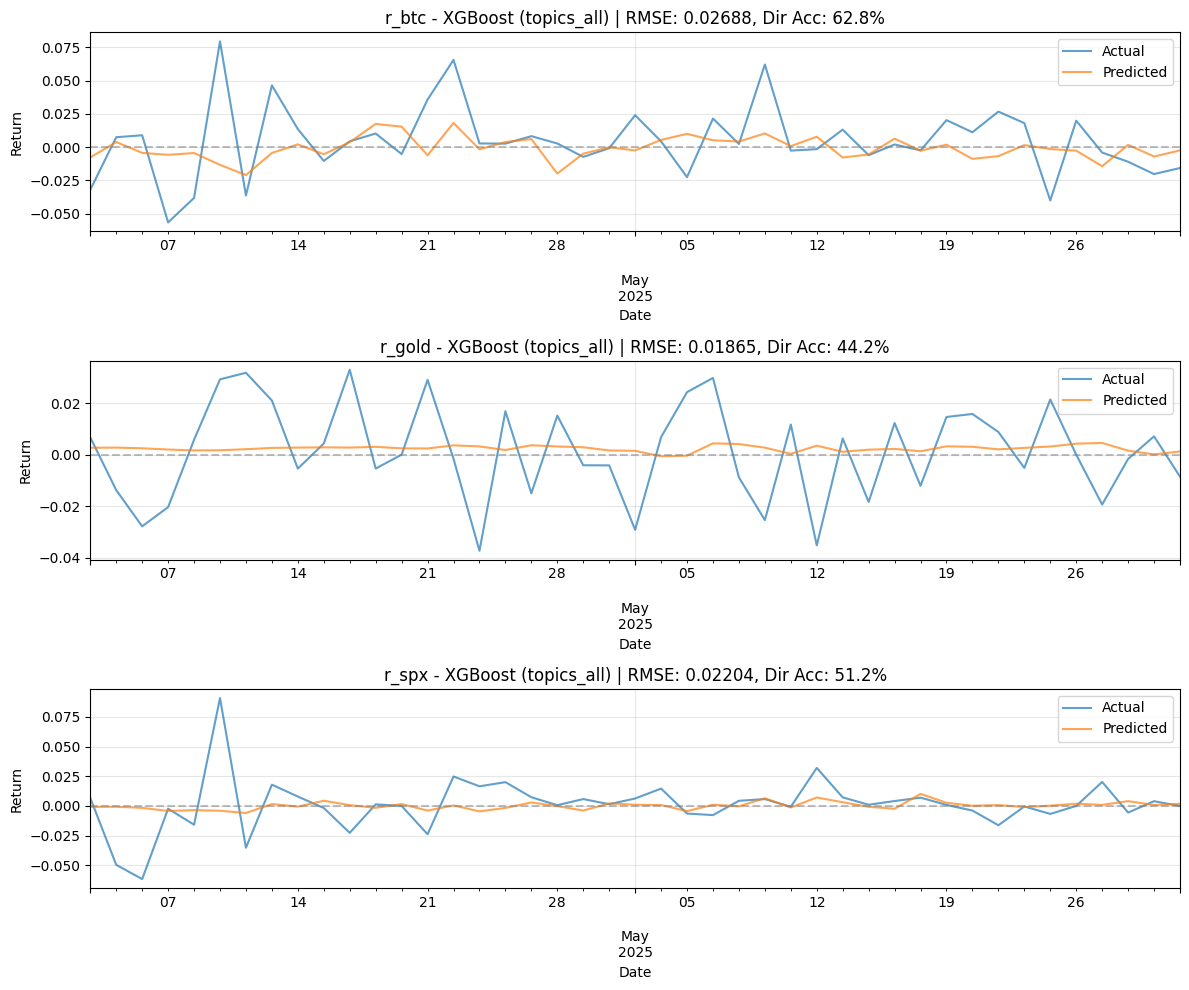

In [26]:
# Plot predictions vs actuals for the best model
print("=" * 70)
print("PREDICTIONS VS ACTUALS")
print("=" * 70)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for idx, asset in enumerate(assets):
    result = all_results[best_model_type][asset]
    
    if "error" not in result:
        ax = axes[idx]
        
        # Plot actual vs predicted
        result['actuals'].plot(ax=ax, label='Actual', alpha=0.7)
        result['predictions'].plot(ax=ax, label='Predicted', alpha=0.7)
        
        ax.set_title(f"{asset} - XGBoost ({best_model_type}) | RMSE: {result['rmse']:.5f}, Dir Acc: {result['dir_acc']:.1f}%")
        ax.set_xlabel('Date')
        ax.set_ylabel('Return')
        ax.legend()
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

CUMULATIVE RETURNS: STRATEGY VS BUY-AND-HOLD
r_btc: Buy & Hold = 20.22%, Strategy = 20.10%
r_gold: Buy & Hold = 4.68%, Strategy = -1.62%
r_spx: Buy & Hold = 3.85%, Strategy = 11.73%


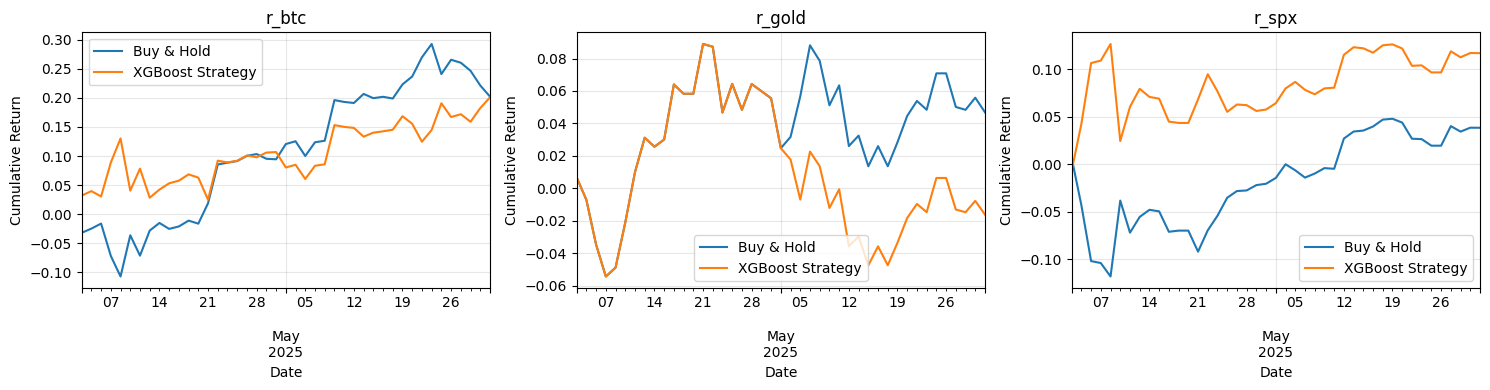

In [27]:
# Plot cumulative returns: strategy vs buy-and-hold
print("=" * 70)
print("CUMULATIVE RETURNS: STRATEGY VS BUY-AND-HOLD")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, asset in enumerate(assets):
    result = all_results[best_model_type][asset]
    
    if "error" not in result:
        ax = axes[idx]
        
        actuals = result['actuals']
        predictions = result['predictions']
        
        # Strategy returns: go long if predicted > 0, else stay out (0 return)
        strategy_returns = actuals * np.sign(predictions)
        
        # Cumulative returns
        cum_actual = (1 + actuals).cumprod() - 1
        cum_strategy = (1 + strategy_returns).cumprod() - 1
        
        cum_actual.plot(ax=ax, label='Buy & Hold')
        cum_strategy.plot(ax=ax, label='XGBoost Strategy')
        
        ax.set_title(f"{asset}")
        ax.set_xlabel('Date')
        ax.set_ylabel('Cumulative Return')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Print final returns
        print(f"{asset}: Buy & Hold = {cum_actual.iloc[-1]*100:.2f}%, Strategy = {cum_strategy.iloc[-1]*100:.2f}%")

plt.tight_layout()
plt.show()

## 11. Final Summary & Conclusions

In [29]:
# Final summary table
print("=" * 80)
print("🏆 FINAL XGBOOST MODEL SUMMARY")
print("=" * 80)

# Best model for each asset
print("Best Model Configuration for Each Asset:")
print("-" * 60)

for asset in assets:
    # Find best by RMSE
    best_rmse_model = "Baseline"
    best_rmse = baseline_results[asset]["rmse"]
    
    for model_type in model_types:
        result = all_results[model_type][asset]
        if "error" not in result and result["rmse"] < best_rmse:
            best_rmse = result["rmse"]
            best_rmse_model = model_type
    
    # Find best by Dir Acc
    best_dir_model = "Baseline"
    best_dir = baseline_results[asset]["dir_acc"]
    
    for model_type in model_types:
        result = all_results[model_type][asset]
        if "error" not in result and result["dir_acc"] > best_dir:
            best_dir = result["dir_acc"]
            best_dir_model = model_type
    
    print(f"{asset.upper()}:")
    print(f"  Best by RMSE: {best_rmse_model} (RMSE = {best_rmse:.5f})")
    print(f"  Best by Dir Acc: {best_dir_model} (Dir Acc = {best_dir:.2f}%)")
    
    # Improvement over baseline
    baseline_rmse = baseline_results[asset]["rmse"]
    baseline_dir = baseline_results[asset]["dir_acc"]
    
    rmse_imp = (baseline_rmse - best_rmse) / baseline_rmse * 100
    dir_imp = best_dir - baseline_dir
    
    print(f"  RMSE improvement: {rmse_imp:+.2f}%")
    print(f"  Dir Acc improvement: {dir_imp:+.2f}pp")



🏆 FINAL XGBOOST MODEL SUMMARY
Best Model Configuration for Each Asset:
------------------------------------------------------------
R_BTC:
  Best by RMSE: Baseline (RMSE = 0.02543)
  Best by Dir Acc: topics_all (Dir Acc = 62.79%)
  RMSE improvement: +0.00%
  Dir Acc improvement: +9.30pp
R_GOLD:
  Best by RMSE: topics_all (RMSE = 0.01865)
  Best by Dir Acc: topics_focus (Dir Acc = 48.84%)
  RMSE improvement: +3.29%
  Dir Acc improvement: +4.65pp
R_SPX:
  Best by RMSE: topics_all (RMSE = 0.02204)
  Best by Dir Acc: topics_focus (Dir Acc = 53.49%)
  RMSE improvement: +3.69%
  Dir Acc improvement: +11.63pp


In [30]:
# Key findings
print("" + "=" * 80)
print("📋 KEY FINDINGS")
print("=" * 80)
print("""
1. TOPIC-LEVEL SIGNALS:
   - Feature selection trimmed the full topic set down to the strongest predictors; see the topic importance table.
   - Aggregated importance shows which topic clusters (e.g., Environmental and Infrastructure, Economic/Financial) matter most for each asset.

2. MODEL PERFORMANCE:
   - Topic-based models are compared against the baseline without EPI; improvements are summarized above.
   - Directional accuracy helps gauge trading usefulness alongside RMSE.

3. ROBUSTNESS:
   - Rolling, expanding-window validation and regularization mitigate overfitting, but sample size remains limited.
   - Revisit the overfitting diagnostics if extending the sample or adjusting lags.

4. NEXT STEPS:
   - Stress-test with alternative lag lengths or different feature thresholds.
   - Combine top topics with other market indicators to see if explanatory power improves.
""")



📋 KEY FINDINGS

1. TOPIC-LEVEL SIGNALS:
   - Feature selection trimmed the full topic set down to the strongest predictors; see the topic importance table.
   - Aggregated importance shows which topic clusters (e.g., Environmental and Infrastructure, Economic/Financial) matter most for each asset.

2. MODEL PERFORMANCE:
   - Topic-based models are compared against the baseline without EPI; improvements are summarized above.
   - Directional accuracy helps gauge trading usefulness alongside RMSE.

3. ROBUSTNESS:
   - Rolling, expanding-window validation and regularization mitigate overfitting, but sample size remains limited.
   - Revisit the overfitting diagnostics if extending the sample or adjusting lags.

4. NEXT STEPS:
   - Stress-test with alternative lag lengths or different feature thresholds.
   - Combine top topics with other market indicators to see if explanatory power improves.



In [ ]:
# Export results
print("" + "=" * 80)
print("EXPORTING RESULTS")
print("=" * 80)

# Save comparison dataframe
comparison_df.to_csv(OUTPUT_DIR + "xgboost_topic_comparison_results.csv", index=False)
print(f"Saved comparison results to: {OUTPUT_DIR}xgboost_topic_comparison_results.csv")

# Save improvement dataframe
improvement_df.to_csv(OUTPUT_DIR + "xgboost_topic_improvement_results.csv", index=False)
print(f"Saved improvement results to: {OUTPUT_DIR}xgboost_topic_improvement_results.csv")

print("✅ Topic-level XGBoost analysis complete!")